In [1]:
print("Student Performance Prediction")


Student Performance Prediction


In [2]:
import pandas as pd


In [3]:
data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 3, 5, 6],
    "Attendance": [65, 70, 75, 80, 85, 90, 95, 72, 82, 88],
    "Previous_Score": [55, 60, 65, 70, 72, 78, 85, 62, 68, 76],
    "Sleep_Hours": [5, 6, 6, 7, 7, 8, 8, 5, 7, 7],
    "Final_Score": [50, 55, 62, 68, 75, 82, 90, 58, 70, 80]
}


In [4]:
df = pd.DataFrame(data)


In [5]:
df


,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
0,2,65,55,5,50
1,3,70,60,6,55
2,4,75,65,6,62
3,5,80,70,7,68
4,6,85,72,7,75
5,7,90,78,8,82
6,8,95,85,8,90
7,3,72,62,5,58
8,5,82,68,7,70
9,6,88,76,7,80


In [6]:
df.head()


,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
0,2,65,55,5,50
1,3,70,60,6,55
2,4,75,65,6,62
3,5,80,70,7,68
4,6,85,72,7,75


In [7]:
df.shape


(10, 5)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     10 non-null     int64
 1   Attendance      10 non-null     int64
 2   Previous_Score  10 non-null     int64
 3   Sleep_Hours     10 non-null     int64
 4   Final_Score     10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [9]:
df.describe()

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
count,10.000000,10.000000,10.000000,10.000000,10.00000
mean,4.900000,80.200000,69.100000,6.600000,69.00000
std,1.911951,9.612492,9.060905,1.074968,12.89272
min,2.000000,65.000000,55.000000,5.000000,50.00000
25%,3.250000,72.750000,62.750000,6.000000,59.00000
50%,5.000000,81.000000,69.000000,7.000000,69.00000
75%,6.000000,87.250000,75.000000,7.000000,78.75000
max,8.000000,95.000000,85.000000,8.000000,90.00000


In [10]:
df.isnull().sum()

Study_Hours       0
Attendance        0
Previous_Score    0
Sleep_Hours       0
Final_Score       0
dtype: int64

In [11]:
df

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
0,2,65,55,5,50
1,3,70,60,6,55
2,4,75,65,6,62
3,5,80,70,7,68
4,6,85,72,7,75
5,7,90,78,8,82
6,8,95,85,8,90
7,3,72,62,5,58
8,5,82,68,7,70
9,6,88,76,7,80


In [12]:
df.corr()

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score
Study_Hours,1.000000,0.992700,0.988352,0.951476,0.991651
Attendance,0.992700,1.000000,0.988415,0.933353,0.997866
Previous_Score,0.988352,0.988415,1.000000,0.917163,0.992032
Sleep_Hours,0.951476,0.933353,0.917163,1.000000,0.921967
Final_Score,0.991651,0.997866,0.992032,0.921967,1.000000


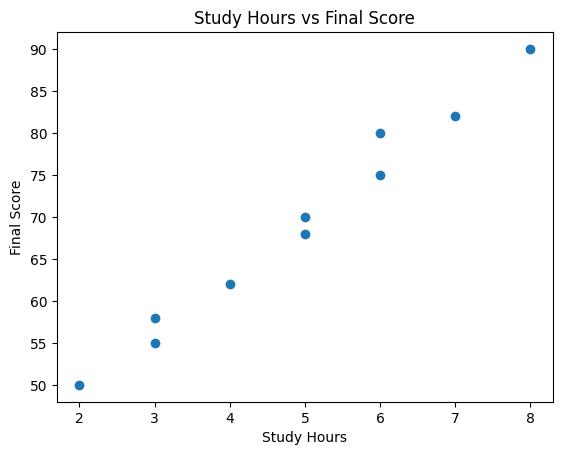

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["Study_Hours"], df["Final_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

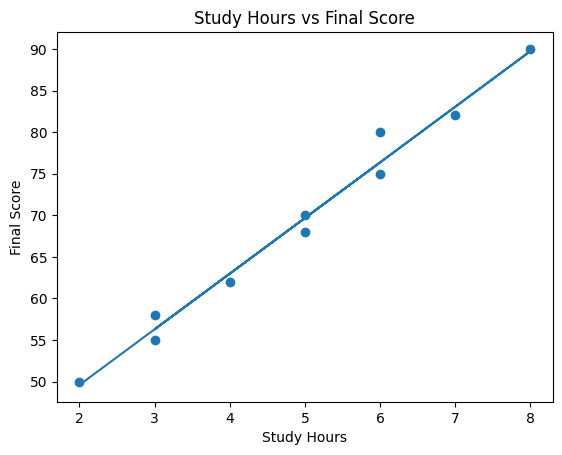

In [14]:
import numpy as np

x = df["Study_Hours"]
y = df["Final_Score"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

In [15]:
print("Slope:", m)
print("Intercept:", b)

Slope: 6.686930091185414
Intercept: 36.23404255319145


In [16]:
predicted_score = m * 6 + b
print("Predicted Final Score:", predicted_score)

Predicted Final Score: 76.35562310030394


In [17]:
from sklearn.metrics import r2_score

y_pred = m * x + b
r2 = r2_score(y, y_pred)

print("R-squared:", r2)

R-squared: 0.9833720722331486


In [18]:
df["Predicted_Score"] = m * df["Study_Hours"] + b

df

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score,Predicted_Score
0,2,65,55,5,50,49.607903
1,3,70,60,6,55,56.294833
2,4,75,65,6,62,62.981763
3,5,80,70,7,68,69.668693
4,6,85,72,7,75,76.355623
5,7,90,78,8,82,83.042553
6,8,95,85,8,90,89.729483
7,3,72,62,5,58,56.294833
8,5,82,68,7,70,69.668693
9,6,88,76,7,80,76.355623


In [19]:
df["Error"] = df["Final_Score"] - df["Predicted_Score"]

df

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Final_Score,Predicted_Score,Error
0,2,65,55,5,50,49.607903,0.392097
1,3,70,60,6,55,56.294833,-1.294833
2,4,75,65,6,62,62.981763,-0.981763
3,5,80,70,7,68,69.668693,-1.668693
4,6,85,72,7,75,76.355623,-1.355623
5,7,90,78,8,82,83.042553,-1.042553
6,8,95,85,8,90,89.729483,0.270517
7,3,72,62,5,58,56.294833,1.705167
8,5,82,68,7,70,69.668693,0.331307
9,6,88,76,7,80,76.355623,3.644377


In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(df["Final_Score"], df["Predicted_Score"])

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2686930091185418


In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df["Final_Score"], df["Predicted_Score"]))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.5771930743954499


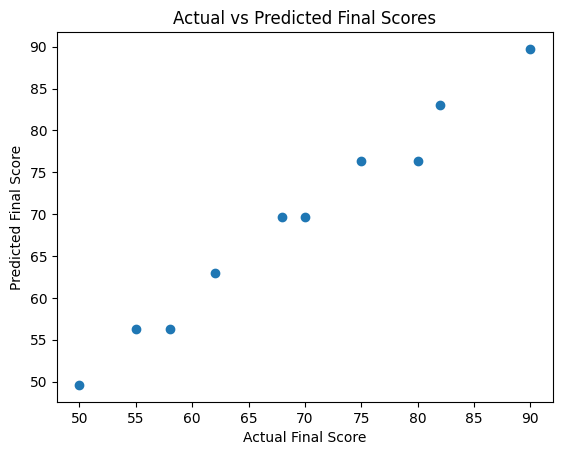

In [22]:
plt.scatter(df["Final_Score"], df["Predicted_Score"])
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()

In [24]:
predict_score(6)

np.float64(76.35562310030394)

In [23]:
def predict_score(study_hours):
    return m * study_hours + b